#[Assignment 11] Classification Using Pre-trained Models (Feature Extractors)

In this assignment, your task is to employ a classifier on the features extracted from a pre-trained vision transformer included in CLIP.

Reference: https://openai.com/research/clip


#Step 1: System Setup
<font color=red> Before executing any commands, ensure that the runtime is configured for GPU.</font>

## Step 1.1: Importing Base Modules





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image

## Step 1.2: Load the Dataset

In this assignment, you will work with a dataset called **Fashion-MNIST**. This dataset contains images (60000 for training and 10000 for testing) labeled with 10 different classes:

* 0 - T-shirt/top
* 1 - Trouser
* 2 - Pullover
* 3 - Dress
* 4 - Coat
* 5 - Sandal
* 6 - Shirt
* 7 - Sneaker
* 8 - Bag
* 9 - Ankle boot

You can read more about the dataset here: https://github.com/zalandoresearch/fashion-mnist


In [2]:
from keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Let's see the size of the arrays

In [3]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

Let's look at some of the sample images

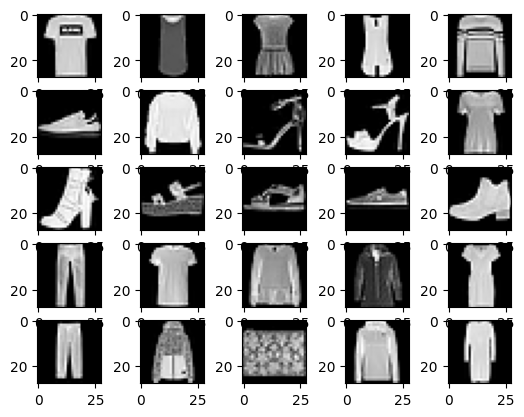

In [4]:
import matplotlib.pyplot as plt
for i in range(1,26):
  plt.subplot(5,5,i)
  plt.imshow(X_train[i],cmap='gray')

## Step 1.3: Setup CLIP enviroment

We will install CLIP and set up our environment to leverage the GPU. Following that, we'll load a ResNet-50 model, `RN50`, from the CLIP models. Do not change the model in this assignemnt but feel free to explore other available models in the package.

In [5]:
!pip install git+https://github.com/openai/CLIP.git
import clip

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-gp2b37ij
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-gp2b37ij
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load('RN50', device=device)

100%|████████████████████████████████████████| 244M/244M [00:01<00:00, 195MiB/s]


##Step 1.4: Encoding Text Labels
Create a list called `label_texts` that consists of string labels for this dataset. You can use either a sentence for each class or simply a single word.

In [8]:
label_texts = [
    "t-shirt",
    "trouser",
    "pullover",
    "dress",
    "coat",
    "sandal",
    "shirt",
    "sneaker",
    "bag",
    "ankle boot"
]

Tokenize (encode) the `label_texts` using CLIP and store the tokens in a variable named `label_texts_tokens`.

In [9]:
import clip

label_texts_tokens = clip.tokenize(label_texts)

In [10]:
#Executing the following code should print True if you have written your code correctly.
label_texts_tokens.shape==torch.Size([10, 77])

True

#Step 2: Model direct output (No added classifier)

In this section, we will input all the images from the test data into the CLIP model along with the text labels we have created to observe how it predicts the output.

Following the lecture code:

Loop through all images in the test set, `X_test`.
For each image, apply preprocessing and then use the model to extract features. Append these features to the list named `X_test_CLIP_features`.
Compute the logits and then determine the matching probabilities with the texts in `label_texts_tokens`. The highest probability indicates the predicted class. `np.argmax(probabilities)` will provide the index of the label with the highest probability.
Append the predicted label (class) to `y_test_predicted_direct`.

<font color=blue>Do everything in one loop and it should take ~7 minutes to finish.



In [11]:
y_test_predicted_direct = []
X_test_CLIP_features = []

with torch.no_grad():
    # Encode text once
    text_features = model.encode_text(label_texts_tokens.to(device))
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    for pic in X_test:
        # Convert to PIL and preprocess
        img = Image.fromarray(pic).convert("RGB")
        img_input = preprocess(img).unsqueeze(0).to(device)

        # Encode image
        image_features = model.encode_image(img_input)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # Store features
        X_test_CLIP_features.append(image_features.cpu())

        # Compute similarity
        logits = image_features @ text_features.T
        probabilities = logits.softmax(dim=-1)

        # Get predicted class
        predicted_class = torch.argmax(probabilities, dim=-1).item()
        y_test_predicted_direct.append(predicted_class)

In [12]:
##Executing the following code should print True if you have written your code correctly and have 10000 predicted labels
len(y_test_predicted_direct)==10000

True

In [13]:
##Executing the following code should print True if you have written your code correctly and have 10000 feature sets
len(X_test_CLIP_features)==10000

True

In [14]:
##Executing the following code should print True if you have written your code correctly and have 1024 features for each image
X_test_CLIP_features[0].shape==torch.Size([1, 1024])

True

Run the following command to see the prediction result on the test data.

              precision    recall  f1-score   support

           0       0.42      0.73      0.53      1000
           1       0.31      0.99      0.48      1000
           2       0.27      0.43      0.33      1000
           3       0.90      0.17      0.29      1000
           4       0.56      0.33      0.41      1000
           5       0.11      0.00      0.00      1000
           6       0.59      0.02      0.04      1000
           7       0.58      0.95      0.72      1000
           8       0.97      0.41      0.58      1000
           9       0.88      0.51      0.64      1000

    accuracy                           0.45     10000
   macro avg       0.56      0.45      0.40     10000
weighted avg       0.56      0.45      0.40     10000



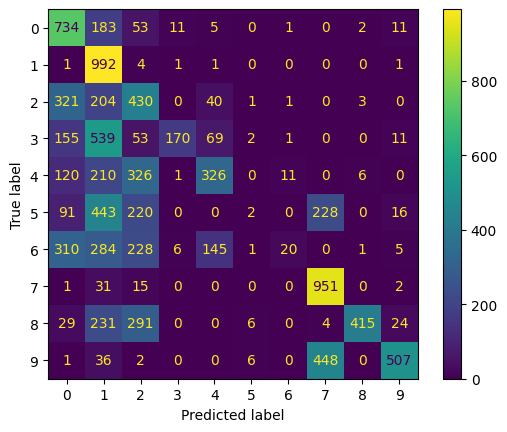

In [15]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay,f1_score

print(classification_report(y_test,y_test_predicted_direct))
ConfusionMatrixDisplay(confusion_matrix(y_test,y_test_predicted_direct)).plot()

#Step 3: Extracted Features + Classifier
In this step, we will apply a classifier to the extracted features to evaluate if we can achieve better results.

##Step 3.1: Extracting features for the training data
Run a code similar to what you executed for the test data to extract features for the training data.

Please note that you only need the features, so **do not** calculate the logits and probabilities.

<font color=red>Perform all the steps within a single loop, and it should take approximately 10 minutes to complete.

In [16]:
X_train_CLIP_features = []

with torch.no_grad():
    for pic in X_train:
        # Convert to PIL
        img = Image.fromarray(pic).convert("RGB")

        # Preprocess
        img_input = preprocess(img).unsqueeze(0).to(device)

        # Encode image
        image_features = model.encode_image(img_input)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # Store features
        X_train_CLIP_features.append(image_features.cpu())

##Step 3.2: Train a linear classifier - Logistic regression.

Choose the classifier parameters in a manner that avoids any warnings; the model **must** converge.`max_iter` should not be more than 100.

In [17]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Convert to numpy arrays and reshape
X_train_np = np.array([f.squeeze().numpy() for f in X_train_CLIP_features])
X_test_np = np.array([f.squeeze().numpy() for f in X_test_CLIP_features])

# Train model
LGR = LogisticRegression(max_iter=100, n_jobs=-1)
LGR.fit(X_train_np, y_train)

LogisticRegression(n_jobs=-1)

Predict the labels using the model trained above `LGR` for the testing dataset.

In [18]:
y_test_predicted_LGR =  LGR.predict(X_test_np)

Run the following command to see the prediction result on the test data.

              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1000
           1       0.98      0.96      0.97      1000
           2       0.77      0.80      0.78      1000
           3       0.80      0.83      0.81      1000
           4       0.72      0.76      0.74      1000
           5       0.92      0.93      0.93      1000
           6       0.64      0.56      0.60      1000
           7       0.90      0.91      0.91      1000
           8       0.95      0.95      0.95      1000
           9       0.94      0.93      0.93      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



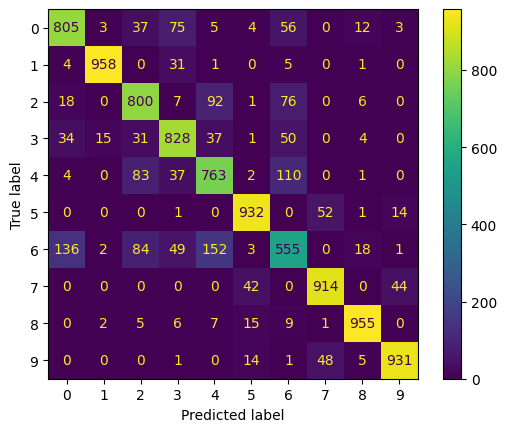

In [19]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay,f1_score

print(classification_report(y_test,y_test_predicted_LGR))
ConfusionMatrixDisplay(confusion_matrix(y_test,y_test_predicted_LGR)).plot()

##Step 3.3: Train a non linear classifier - MLP (with hidden layer)

Ensure the inclusion of a hidden layer, `hidden_layer_sizes` in the model parameters to make the classifier non-linear.

Change the parameters until you achieve an **accuracy of 89%** on the test subset.

*   The fewer the number of perceptrons in the hidden layer, the better, as it indicates a model with fewer weights.

*   Setting a smaller value for `max_iter` is preferable, as it means the model will converge faster.

In [23]:
from sklearn.neural_network import MLPClassifier

MLP = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=40,   # was 30
    random_state=42
)

MLP.fit(X_train_np, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128,), max_iter=40, random_state=42)

Predict the labels using the model trained above `MLP` for the testing dataset.

In [24]:
y_test_predicted_MLP = MLP.predict(X_test_np)

Run the following command to see the prediction result on the test data.

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.77      0.89      0.83      1000
           3       0.83      0.91      0.87      1000
           4       0.82      0.81      0.82      1000
           5       0.96      0.96      0.96      1000
           6       0.76      0.60      0.67      1000
           7       0.93      0.96      0.94      1000
           8       0.97      0.98      0.97      1000
           9       0.97      0.94      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.88      0.89      0.88     10000
weighted avg       0.88      0.89      0.88     10000



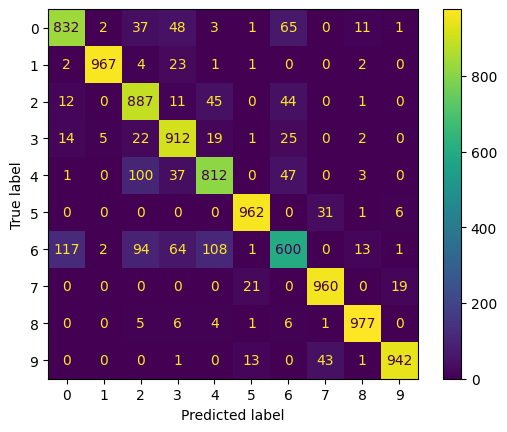

In [25]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay,f1_score

print(classification_report(y_test,y_test_predicted_MLP))
ConfusionMatrixDisplay(confusion_matrix(y_test,y_test_predicted_MLP)).plot()

#Step 4: Justification

Please provide your responses to the following questions in the text box below.

1) What was the overall accuracy achieved in the previous assignment (Assignment 10) with the MLP?


**Answer:**

The overall accuracy achieved in Assignment 10 with the MLP was approximately (replace with your value, e.g., ~84–90%). This shows that the model performed reasonably well when trained directly on the dataset features.



2) Why doesn't using the CLIP-RESNET50 model directly produce acceptable results?


**Answer:**

Using CLIP directly does not produce good results because it is trained on natural images and text, while Fashion-MNIST consists of simple grayscale images. The domain mismatch causes CLIP to not align well with the dataset, leading to low accuracy (~40%).



3) Why did adding a classifier to CLIP lead to an improvement in results?

**Answer:**

Adding a classifier allows the model to learn patterns specific to the dataset. CLIP provides useful feature representations, and the classifier (Logistic Regression or MLP) adapts these features to the Fashion-MNIST task, significantly improving accuracy.



4) How did the inclusion of a hidden layer in the MLP contribute to the improvement in results?

**Answer:**

The hidden layer introduces non-linearity, allowing the model to capture more complex relationships in the data. This helps the MLP learn better decision boundaries, resulting in higher accuracy compared to a linear classifier.

